<a href="https://colab.research.google.com/github/danielchacon170-gif/artificial-intelligence-2025/blob/main/red_neuronal_multicapa/Red_multicapa_predicci%C3%B3n_de_adeudo.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

class_weight: {0: 0.6420202236370446, 1: 2.2603126765869277}
Epoch 1/200
38/38 ━━━━━━━━━━━━━━━━━━━━ 6s 68ms/step - accuracy: 0.5995 - loss: 0.6846 - val_accuracy: 0.7437 - val_loss: 0.6066
Epoch 2/200
38/38 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.7299 - loss: 0.6076 - val_accuracy: 0.7473 - val_loss: 0.5781
Epoch 3/200
38/38 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.7311 - loss: 0.5972 - val_accuracy: 0.7575 - val_loss: 0.5778
Epoch 4/200
38/38 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.7395 - loss: 0.5862 - val_accuracy: 0.7442 - val_loss: 0.5856
Epoch 5/200
38/38 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.7414 - loss: 0.5831 - val_accuracy: 0.7419 - val_loss: 0.5785
Epoch 6/200
38/38 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.7414 - loss: 0.5755 - val_accuracy: 0.7350 - val_loss: 0.5843
Epoch 7/200
38/38 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.7422 - loss: 0.5823 - val_accuracy: 0.7515 - val_loss: 0.5653
Epoch 8/200
38/38 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/ste

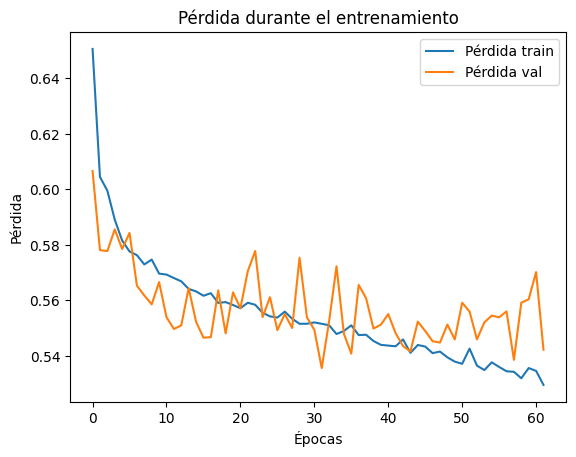

Accuracy en test (t=0.50): 0.7640
188/188 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step
   Actual  Predicted_Prob  Predicted_Label
0       0        0.252840                0
1       0        0.293495                0
2       0        0.380290                0
3       1        0.305412                0
4       0        0.151596                0
Matriz de Confusión (t=0.50):
 [[3775  898]
 [ 518  809]]

Classification Report (t=0.50):
              precision    recall  f1-score   support

           0      0.879     0.808     0.842      4673
           1      0.474     0.610     0.533      1327

    accuracy                          0.764      6000
   macro avg      0.677     0.709     0.688      6000
weighted avg      0.790     0.764     0.774      6000

ROC-AUC: 0.7741 | F1: 0.5333 | Precision: 0.4739 | Recall: 0.6096


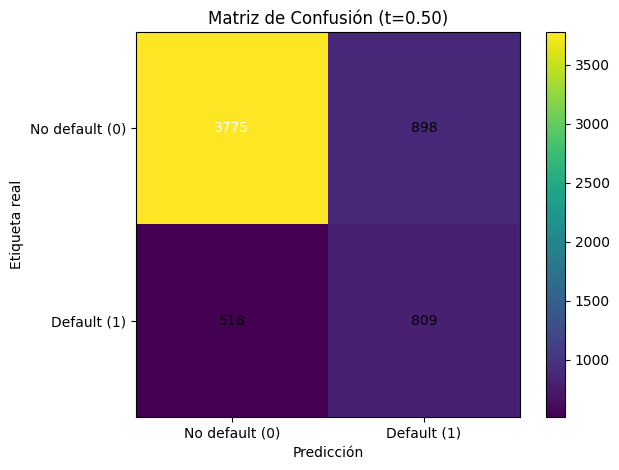


Mejor umbral por F2: 0.250 | F2=0.6309
Matriz de Confusión (umbral óptimo F2):
 [[1519 3154]
 [ 105 1222]]

Classification Report (umbral óptimo F2):
              precision    recall  f1-score   support

           0      0.935     0.325     0.482      4673
           1      0.279     0.921     0.429      1327

    accuracy                          0.457      6000
   macro avg      0.607     0.623     0.455      6000
weighted avg      0.790     0.457     0.471      6000

ROC-AUC: 0.7741 | PR-AUC: 0.5455


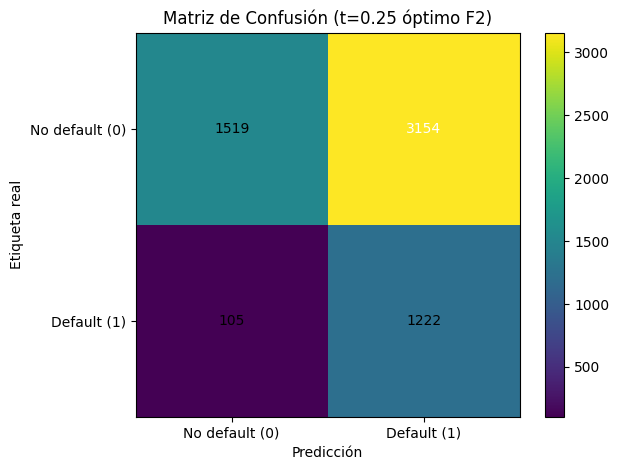

In [ ]:
#Marco Ramire
#Daniel Chacón


import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.utils.class_weight import compute_class_weight
from sklearn.metrics import (
    confusion_matrix, classification_report, roc_auc_score, f1_score,
    precision_score, recall_score, fbeta_score, average_precision_score
)

from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout, BatchNormalization, Input
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.regularizers import l2
from tensorflow.keras.callbacks import EarlyStopping

# ---------- 1) Carga ----------
url = "https://raw.githubusercontent.com/RamirezArizpe/Ciencia-de-datos-para-negocios/UCA-Inteligencia-Artificial/Redes%20neuronales%20multicapa/UCI_Credit_Card.csv"
df = pd.read_csv(url)
df  # en notebook, muestra la tabla para inspección

# ---------- 2) Normalización de categorías según documentación ----------
# EDUCATION: 0/5/6 -> 4 (otros). MARRIAGE: 0 -> 3 (otros)
df['EDUCATION'] = df['EDUCATION'].replace({0:4, 5:4, 6:4})
df['MARRIAGE']  = df['MARRIAGE'].replace({0:3})

# ---------- 3) Limpieza mínima coherente con la ficha técnica ----------
# 3.1 Retrasos (PAY_*) a rango razonable [-2..8] para evitar códigos fuera de rango
for c in ['PAY_0','PAY_2','PAY_3','PAY_4','PAY_5','PAY_6']:
    df[c] = df[c].clip(-2, 8)

# 3.2 Montos negativos en facturas/pagos no son válidos -> se recortan a 0
for col in [f'BILL_AMT{k}' for k in range(1,7)] + [f'PAY_AMT{k}' for k in range(1,7)]:
    df[col] = df[col].clip(lower=0)

# 3.3 Edad a rango [18,80] para controlar outliers
df['AGE'] = df['AGE'].clip(18, 80)

# 3.4 Límites de crédito no nulos/negativos (cuentas canceladas o error) -> mínimo 1000
df['LIMIT_BAL'] = df['LIMIT_BAL'].clip(lower=1000)

# ---------- 4) Ingeniería de variables con salvaguardas numéricas ----------
# Utilización por mes: BILL / LIMIT (con +1 en denom por seguridad) y límite superior (200%)
for k in range(1,7):
    util = df[f'BILL_AMT{k}'] / (df['LIMIT_BAL'] + 1.0)
    df[f'UTIL_{k}'] = np.clip(util, 0.0, 2.0)  # 0%..200%

# Ratio de pago por mes: PAY / (BILL+1); si BILL=0 -> ratio=PAY; acotar a [0,2]
for k in range(1,7):
    bill = df[f'BILL_AMT{k}'].astype(float)
    pay  = df[f'PAY_AMT{k}'].astype(float)
    denom = bill + 1.0
    denom_safe = np.where(denom <= 0.0, 1.0, denom)  # evita 0/negativos
    payr = pay / denom_safe
    df[f'PAYR_{k}'] = np.clip(payr, 0.0, 2.0)

# Agregados globales
df['TOTAL_BILL'] = df[[f'BILL_AMT{k}' for k in range(1,7)]].sum(axis=1)
df['TOTAL_PAY']  = df[[f'PAY_AMT{k}'  for k in range(1,7)]].sum(axis=1)

# Ratio global de pago vs facturación con denominador seguro
denom_total = np.where((df['TOTAL_BILL'] + 1.0) <= 0.0, 1.0, df['TOTAL_BILL'] + 1.0)
df['PAY_TO_BILL_RATIO'] = np.clip(df['TOTAL_PAY'] / denom_total, 0.0, 2.0)

# Tendencia de deuda relativa al límite (dinámica sensible al tamaño de línea)
df['BILL_TREND_REL'] = (df['BILL_AMT6'] - df['BILL_AMT1']) / (df['LIMIT_BAL'] + 1.0)

# Severidad y persistencia de morosidad
df['MAX_DELAY']  = df[[f'PAY_{k}' for k in [0,2,3,4,5,6]]].max(axis=1)
df['MEAN_DELAY'] = df[[f'PAY_{k}' for k in [0,2,3,4,5,6]]].mean(axis=1)

# Transformaciones log1p para colas largas de montos y límite
for c in ['LIMIT_BAL'] + [f'BILL_AMT{k}' for k in range(1,7)] + [f'PAY_AMT{k}' for k in range(1,7)]:
    df[f'LOG1P_{c}'] = np.log1p(df[c].astype(float))  # ya no hay negativos tras el clip

# 5) Conjunto de features y target
base_features = [
    'LIMIT_BAL','SEX','EDUCATION','MARRIAGE','AGE',
    'PAY_0','PAY_2','PAY_3','PAY_4','PAY_5','PAY_6',
    'BILL_AMT1','BILL_AMT2','BILL_AMT3','BILL_AMT4','BILL_AMT5','BILL_AMT6',
    'PAY_AMT1','PAY_AMT2','PAY_AMT3','PAY_AMT4','PAY_AMT5','PAY_AMT6'
]

engineered = (
    [f'UTIL_{k}' for k in range(1,7)] +
    [f'PAYR_{k}' for k in range(1,7)] +
    ['TOTAL_BILL','TOTAL_PAY','PAY_TO_BILL_RATIO','BILL_TREND_REL','MAX_DELAY','MEAN_DELAY'] +
    [f'LOG1P_{c}' for c in ['LIMIT_BAL'] + [f'BILL_AMT{k}' for k in range(1,7)] + [f'PAY_AMT{k}' for k in range(1,7)]]
)

features = base_features + engineered

X = df[features].to_numpy(dtype=float)
y = df['default.payment.next.month'].to_numpy(dtype=int)

# Limpieza final
X = np.nan_to_num(X, copy=False, nan=0.0, posinf=0.0, neginf=0.0)

# ---------- 6) Split + escalado ----------
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test  = scaler.transform(X_test)

# ---------- 7) Pesos de clase (desbalance ~22% impago) ----------
class_weights = compute_class_weight(
    class_weight='balanced', classes=np.array([0,1]), y=y_train
)
class_weight_dict = {0: float(class_weights[0]), 1: float(class_weights[1])}
print("class_weight:", class_weight_dict)

# ---------- 8) Modelo MLP con regularización ----------
model = Sequential([
    Input(shape=(X_train.shape[1],)),
    BatchNormalization(),
    Dense(128, activation='relu', kernel_regularizer=l2(1e-4)),
    Dropout(0.30),
    Dense(64, activation='relu', kernel_regularizer=l2(1e-4)),
    Dropout(0.25),
    Dense(1, activation='sigmoid')
])

model.compile(optimizer=Adam(learning_rate=1e-3),
              loss='binary_crossentropy',
              metrics=['accuracy'])

early = EarlyStopping(monitor='val_loss', patience=30, restore_best_weights=True)

history = model.fit(
    X_train, y_train,
    validation_split=0.2,
    epochs=200,
    batch_size=512,
    verbose=1,
    class_weight=class_weight_dict,
    callbacks=[early]
)

# ---------- 9) Curva de pérdida ----------
plt.plot(history.history['loss'], label='Pérdida train')
plt.plot(history.history['val_loss'], label='Pérdida val')
plt.xlabel('Épocas'); plt.ylabel('Pérdida'); plt.legend()
plt.title('Pérdida durante el entrenamiento'); plt.show()

# ---------- 10) Métricas en test (umbral 0.50) ----------
loss, acc = model.evaluate(X_test, y_test, verbose=0)
print(f"Accuracy en test (t=0.50): {acc:.4f}")

pred_proba = model.predict(X_test).ravel()
pred_050 = (pred_proba >= 0.5).astype(int)

print(pd.DataFrame({
    'Actual': y_test,
    'Predicted_Prob': pred_proba,
    'Predicted_Label': pred_050
}).head())

cm_050 = confusion_matrix(y_test, pred_050)
print("Matriz de Confusión (t=0.50):\n", cm_050)
print("\nClassification Report (t=0.50):")
print(classification_report(y_test, pred_050, digits=3))

auc = roc_auc_score(y_test, pred_proba)
f1  = f1_score(y_test, pred_050)
precision = precision_score(y_test, pred_050)
recall    = recall_score(y_test, pred_050)
print(f"ROC-AUC: {auc:.4f} | F1: {f1:.4f} | Precision: {precision:.4f} | Recall: {recall:.4f}")

plt.figure()
plt.imshow(cm_050, interpolation='nearest')
plt.title('Matriz de Confusión (t=0.50)')
plt.colorbar()
tick_marks = np.arange(2)
plt.xticks(tick_marks, ['No default (0)', 'Default (1)'])
plt.yticks(tick_marks, ['No default (0)', 'Default (1)'])
thresh = cm_050.max() / 2.0
for i in range(cm_050.shape[0]):
    for j in range(cm_050.shape[1]):
        plt.text(j, i, format(cm_050[i, j], 'd'),
                 ha="center", va="center",
                 color="white" if cm_050[i, j] > thresh else "black")
plt.ylabel('Etiqueta real'); plt.xlabel('Predicción'); plt.tight_layout(); plt.show()

# ---------- 11) Umbral óptimo por F2 (recall priorizado) ----------
best_t, best_f2 = 0.5, -1.0
for t in np.linspace(0.05, 0.80, 76):
    pred_t = (pred_proba >= t).astype(int)
    f2 = fbeta_score(y_test, pred_t, beta=2)
    if f2 > best_f2:
        best_f2, best_t = f2, t

print(f"\nMejor umbral por F2: {best_t:.3f} | F2={best_f2:.4f}")

pred_best = (pred_proba >= best_t).astype(int)
cm_best = confusion_matrix(y_test, pred_best)
print("Matriz de Confusión (umbral óptimo F2):\n", cm_best)
print("\nClassification Report (umbral óptimo F2):")
print(classification_report(y_test, pred_best, digits=3))

roc = roc_auc_score(y_test, pred_proba)
pr_auc = average_precision_score(y_test, pred_proba)
print(f"ROC-AUC: {roc:.4f} | PR-AUC: {pr_auc:.4f}")

plt.figure()
plt.imshow(cm_best, interpolation='nearest')
plt.title(f'Matriz de Confusión (t={best_t:.2f} óptimo F2)')
plt.colorbar()
tick_marks = np.arange(2)
plt.xticks(tick_marks, ['No default (0)', 'Default (1)'])
plt.yticks(tick_marks, ['No default (0)', 'Default (1)'])
thresh = cm_best.max() / 2.0
for i in range(cm_best.shape[0]):
    for j in range(cm_best.shape[1]):
        plt.text(j, i, format(cm_best[i, j], 'd'),
                 ha="center", va="center",
                 color="white" if cm_best[i, j] > thresh else "black")
plt.ylabel('Etiqueta real'); plt.xlabel('Predicción'); plt.tight_layout(); plt.show()

In [ ]:
df.describe()

,ID,LIMIT_BAL,SEX,EDUCATION,MARRIAGE,AGE,PAY_0,PAY_2,PAY_3,PAY_4,...,LOG1P_BILL_AMT3,LOG1P_BILL_AMT4,LOG1P_BILL_AMT5,LOG1P_BILL_AMT6,LOG1P_PAY_AMT1,LOG1P_PAY_AMT2,LOG1P_PAY_AMT3,LOG1P_PAY_AMT4,LOG1P_PAY_AMT5,LOG1P_PAY_AMT6
count,30000.000000,30000.000000,30000.000000,30000.000000,30000.000000,30000.000000,30000.000000,30000.000000,30000.000000,30000.000000,...,30000.000000,30000.000000,30000.000000,30000.000000,30000.000000,30000.000000,30000.000000,30000.000000,30000.000000,30000.000000
mean,15000.500000,167484.322667,1.603733,1.842267,1.557267,35.485500,-0.016700,-0.133767,-0.166200,-0.220667,...,8.714646,8.559843,8.397675,8.195965,6.630003,6.562652,6.283188,6.077716,6.032192,5.932831
std,8660.398374,129747.661567,0.489129,0.744494,0.521405,9.217904,1.123802,1.197186,1.196868,1.169139,...,3.582087,3.663511,3.735936,3.886027,3.250304,3.278754,3.349722,3.396598,3.443995,3.528092
min,1.000000,10000.000000,1.000000,1.000000,1.000000,21.000000,-2.000000,-2.000000,-2.000000,-2.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,7500.750000,50000.000000,1.000000,1.000000,1.000000,28.000000,-1.000000,-1.000000,-1.000000,-1.000000,...,7.888803,7.752657,7.475339,7.136483,6.908755,6.726233,5.968708,5.693732,5.535358,4.777014
50%,15000.500000,140000.000000,2.000000,2.000000,2.000000,34.000000,0.000000,0.000000,0.000000,0.000000,...,9.907953,9.854980,9.803971,9.745195,7.650169,7.605890,7.496097,7.313887,7.313887,7.313887
75%,22500.250000,240000.000000,2.000000,2.000000,2.000000,41.000000,0.000000,0.000000,0.000000,0.000000,...,11.004859,10.906084,10.823601,10.803634,8.518592,8.517393,8.413165,8.297606,8.302142,8.294300
max,30000.000000,1000000.000000,2.000000,4.000000,3.000000,79.000000,8.000000,8.000000,8.000000,8.000000,...,14.324789,13.700758,13.739894,13.776421,13.680324,14.336837,13.705741,13.339088,12.963438,13.178114


In [ ]:
# Inserta tus propios valores para probar y predecir

# Como ejercicio, en este apartado puede ir modificando los datos que se proporcionan de una persona,
# sigue las escalas sugeridas, cada variable las menciona
nuevo_cliente = {
    'LIMIT_BAL': 200000,  # límite de crédito
    'SEX': 2,             # 1=Hombre, 2=Mujer
    'EDUCATION': 2,       # 1=Posgrado, 2=Universidad, 3=Preparatoria, 4=Otro
    'MARRIAGE': 1,        # 1=Casado, 2=Soltero, 3=Otro
    'AGE': 35,

    # Retrasos recientes (0 = al día, 1 al 8 = meses de retraso)
    'PAY_0': 8, 'PAY_2': 1, 'PAY_3': 0, 'PAY_4': 2, 'PAY_5': 0, 'PAY_6': 0,

    # Facturas de los últimos 6 meses
    'BILL_AMT1': 25000, 'BILL_AMT2': 30000, 'BILL_AMT3': 32000,
    'BILL_AMT4': 28000, 'BILL_AMT5': 26000, 'BILL_AMT6': 24000,

    # Pagos de los últimos 6 meses
    'PAY_AMT1': 5000, 'PAY_AMT2': 30000, 'PAY_AMT3': 32000,
    'PAY_AMT4': 28000, 'PAY_AMT5': 26000, 'PAY_AMT6': 24000
}

# ---------- Fin del apartado de inserción manual de datos ---------------------

# Convertir a DataFrame
nuevo_df = pd.DataFrame([nuevo_cliente])

# Repetir el mismo proceso de limpieza (igual que al inicio)
for c in ['PAY_0','PAY_2','PAY_3','PAY_4','PAY_5','PAY_6']:
    nuevo_df[c] = nuevo_df[c].clip(-2, 8)
for col in [f'BILL_AMT{k}' for k in range(1,7)] + [f'PAY_AMT{k}' for k in range(1,7)]:
    nuevo_df[col] = nuevo_df[col].clip(lower=0)
nuevo_df['AGE'] = nuevo_df['AGE'].clip(18, 80)
nuevo_df['LIMIT_BAL'] = nuevo_df['LIMIT_BAL'].clip(lower=1000)

# Recalcular los features derivados del modelo original
for k in range(1,7):
    util = nuevo_df[f'BILL_AMT{k}'] / (nuevo_df['LIMIT_BAL'] + 1)
    nuevo_df[f'UTIL_{k}'] = np.clip(util, 0.0, 2.0)
for k in range(1,7):
    denom = nuevo_df[f'BILL_AMT{k}'] + 1.0
    # BILL_AMT es -1, que hará el denominador 0.
    denom_safe = np.where(denom <= 0.0, 1.0, denom)
    payr = nuevo_df[f'PAY_AMT{k}'] / denom_safe
    nuevo_df[f'PAYR_{k}'] = np.clip(payr, 0.0, 2.0)
nuevo_df['TOTAL_BILL'] = nuevo_df[[f'BILL_AMT{k}' for k in range(1,7)]].sum(axis=1)
nuevo_df['TOTAL_PAY']  = nuevo_df[[f'PAY_AMT{k}'  for k in range(1,7)]].sum(axis=1)
denom_total = np.where((nuevo_df['TOTAL_BILL'] + 1.0) <= 0.0, 1.0, nuevo_df['TOTAL_BILL'] + 1.0)
nuevo_df['PAY_TO_BILL_RATIO'] = np.clip(
    nuevo_df['TOTAL_PAY'] / denom_total, 0.0, 2.0
)
nuevo_df['BILL_TREND_REL'] = (nuevo_df['BILL_AMT6'] - nuevo_df['BILL_AMT1']) / (nuevo_df['LIMIT_BAL'] + 1.0)
nuevo_df['MAX_DELAY'] = nuevo_df[[f'PAY_{k}' for k in [0,2,3,4,5,6]]].max(axis=1)
nuevo_df['MEAN_DELAY'] = nuevo_df[[f'PAY_{k}' for k in [0,2,3,4,5,6]]].mean(axis=1)

for c in ['LIMIT_BAL'] + [f'BILL_AMT{k}' for k in range(1,7)] + [f'PAY_AMT{k}' for k in range(1,7)]:
    nuevo_df[f'LOG1P_{c}'] = np.log1p(nuevo_df[c].astype(float))

# Tomar las columnas del modelo original (features)

base_features = [
    'LIMIT_BAL','SEX','EDUCATION','MARRIAGE','AGE',
    'PAY_0','PAY_2','PAY_3','PAY_4','PAY_5','PAY_6',
    'BILL_AMT1','BILL_AMT2','BILL_AMT3','BILL_AMT4','BILL_AMT5','BILL_AMT6',
    'PAY_AMT1','PAY_AMT2','PAY_AMT3','PAY_AMT4','PAY_AMT5','PAY_AMT6'
]

engineered = (
    [f'UTIL_{k}' for k in range(1,7)] +
    [f'PAYR_{k}' for k in range(1,7)] +
    ['TOTAL_BILL','TOTAL_PAY','PAY_TO_BILL_RATIO','BILL_TREND_REL','MAX_DELAY','MEAN_DELAY'] +
    [f'LOG1P_{c}' for c in ['LIMIT_BAL'] + [f'BILL_AMT{k}' for k in range(1,7)] + [f'PAY_AMT{k}' for k in range(1,7)]]
)

features = base_features + engineered

X_nuevo = nuevo_df[features].to_numpy(dtype=float)
X_nuevo = np.nan_to_num(X_nuevo, nan=0.0, posinf=0.0, neginf=0.0)

# Escalar con el mismo scaler del entrenamiento
X_nuevo = scaler.transform(X_nuevo)

# Predecir
probabilidad_impago = model.predict(X_nuevo)[0][0]
print(f"\nProbabilidad de impago: {probabilidad_impago:.3f}")

# Puedes decidir el resultado según el umbral que uses
umbral = 0.34  # el mejor para F2 según tu modelo
prediccion = 1 if probabilidad_impago >= umbral else 0
print(f"Predicción final (umbral={umbral}): {'Mal pagador' if prediccion==1 else 'Buen pagador'}")

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 28ms/step

Probabilidad de impago: 0.999
Predicción final (umbral=0.34): Mal pagador
